<a href="https://colab.research.google.com/github/api-sage/diaml_projects/blob/main/Project4/pafolabi_DIAML_Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data, Inference, and Applied Machine Learning - Assignment 4

In [1]:
#Importation of libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
import scipy as scp
from scipy import stats

##Question 1

Dataset: [Monthly House Price Data](https://github.com/api-sage/diaml_projects/raw/refs/heads/main/Project4/data/Monthly.csv
)

In [2]:
#Data ingestion
house_url = 'https://github.com/api-sage/diaml_projects/raw/refs/heads/main/Project4/data/Monthly.csv'
ftse_url = 'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project4/data/FTSE100.csv'

house = pd.read_csv(house_url)
ftse = pd.read_csv(ftse_url)

#Clean the house price data
house['Date'] = pd.to_datetime(house['Mon-YY'], format='%b-%y')
house['HousePrice'] = house['Average House Price'].str.replace('[£,]', '', regex=True).astype(float)
ftse['Date'] = pd.to_datetime(ftse['Date'])

#Join on month and keep January 1991 to August 2026
df = house[['Date', 'HousePrice']].merge(ftse[['Date', 'Close']], on='Date').sort_values('Date')
df = df[(df['Date'] >= '1991-01-01') & (df['Date'] <= '2026-08-31')].reset_index(drop=True)
print(df.shape, df['Date'].min(), df['Date'].max())
df.head()

(428, 3) 1991-01-01 00:00:00 2026-08-01 00:00:00


,Date,HousePrice,Close
0,1991-01-01,53052.0,2170.300049
1,1991-02-01,53497.0,2380.899902
2,1991-03-01,52893.0,2456.500000
3,1991-04-01,53677.0,2486.199951
4,1991-05-01,54386.0,2499.500000


###(a) Fit a linear regression using the raw Average House Price level as the explanatory variable and the raw FTSE100 Close level as the dependent variable. Then compute the monthly return of each series as r(t) = p(t)/p(t−1) − 1, and fit the same regression using returns instead of levels. For both regressions, report the slope, intercept, correlation coefficient, R², and p-value

In [3]:
def fit(x, y):
    s = stats.linregress(x, y)
    return {'Slope': s.slope, 'Intercept': s.intercept, 'Correlation': s.rvalue, 'R squared': s.rvalue**2, 'p-value': s.pvalue}

#Levels
levels_res = fit(df['HousePrice'], df['Close'])

#Returns: r(t) = p(t)/p(t-1) - 1
df['HouseRet'] = df['HousePrice'] / df['HousePrice'].shift(1) - 1
df['FTSERet'] = df['Close'] / df['Close'].shift(1) - 1
ret = df.dropna().reset_index(drop=True)
returns_res = fit(ret['HouseRet'], ret['FTSERet'])

pd.DataFrame({'Levels': levels_res, 'Returns': returns_res})

,Levels,Returns
Slope,1.984993e-02,0.067812
Intercept,2.697443e+03,0.004257
Correlation,8.304780e-01,0.018603
R squared,6.896936e-01,0.000346
p-value,2.621893e-110,0.701484


**My answer to (a):** The table above shows both regressions. On levels, the slope is about 0.0198, the intercept is about 2697, the correlation is about 0.83, R² is about 0.69 and the p-value is far below 0.05. On returns, the slope is about 0.068, the intercept is about 0.0043, the correlation is about 0.019, R² is about 0.0003 and the p-value is about 0.70. So the levels look strongly linked, while the returns show almost nothing.

###(b) These two regressions give strikingly different answers. Explain why, by checking how much of each series's own variation is explained purely by the passage of time.

In [4]:
t_levels = np.arange(len(df))
t_returns = np.arange(len(ret))

time_res = pd.DataFrame({
    'House price level': fit(t_levels, df['HousePrice']),
    'FTSE100 level': fit(t_levels, df['Close']),
    'House price return': fit(t_returns, ret['HouseRet']),
    'FTSE100 return': fit(t_returns, ret['FTSERet']),
}).T
time_res[['Slope', 'R squared', 'p-value']]

,Slope,R squared,p-value
House price level,576.382333,0.958265,5.781094e-296
FTSE100 level,12.210298,0.752758,2.417255e-131
House price return,-0.000007,0.005787,1.165015e-01
FTSE100 return,-0.000009,0.000776,5.658223e-01


**My answer to (b):** Time alone explains about 96% of the variation in house price levels and about 75% of the variation in FTSE100 levels. Both series mostly just go up over the years, so they look related only because they trend together. That is a spurious regression. The high R² of 0.69 in the levels model comes from the shared upward trend and says little about a real link. Returns remove the trend. Time explains well under 1% of the variation in each return series (R² of about 0.006 and 0.0008). Once the trend is gone, the strong relationship disappears, which is why the two regressions give such different answers. I trust the returns regression more.

###(c) Interpret the slope, intercept, correlation, and R² from the returns-based regression. What does each one tell you about the relationship between house price returns and FTSE returns? Use a hypothesis test to back up your conclusion about whether a significant relationship exists.

In [5]:
#Test H0: slope = 0 against H1: slope != 0 at the 5% level
s = stats.linregress(ret['HouseRet'], ret['FTSERet'])
t_stat = s.slope / s.stderr
print('Slope:', s.slope, 'Std error:', s.stderr)
print('t statistic:', t_stat)
print('p-value:', s.pvalue)
print('Reject H0 at 5%?', s.pvalue < 0.05)

Slope: 0.06781163018403408 Std error: 0.17678787126305096
t statistic: 0.38357625836861836
p-value: 0.7014843456027531
Reject H0 at 5%? False


**My answer to (c):** The slope of about 0.068 means that when house prices rise 1 percentage point in a month, the FTSE100 return is only expected to be about 0.07 percentage points higher. That is tiny. The intercept of about 0.0043 means the FTSE100 is expected to return about 0.43% in a month when house prices do not change. The correlation of about 0.019 is very close to zero, so there is almost no straight line link. R² of about 0.0003 means house price returns explain only about 0.03% of the ups and downs in FTSE returns.

For the hypothesis test, the null hypothesis is that the slope is 0 (no relationship) and the alternative is that it is not 0. The p-value is about 0.70, which is much bigger than 0.05, so I fail to reject the null hypothesis. I do not find a significant relationship between monthly house price returns and FTSE100 returns.

###(d) Slope and correlation are not the same thing; explain what each one is actually telling you, and why a small regression slope can coexist with a strong correlation, and vice versa. Plot the return data points together with the fitted regression line, and discuss what the plot shows in light of your answer.

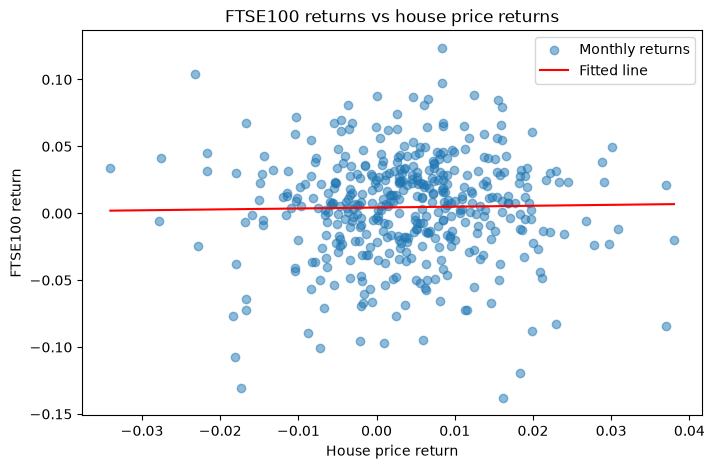

Std of house returns: 0.010598262217279735
Std of FTSE returns: 0.03863285046418408


In [6]:
x = ret['HouseRet']
plt.figure(figsize=(8, 5))
plt.scatter(x, ret['FTSERet'], alpha=0.5, label='Monthly returns')
xs = np.linspace(x.min(), x.max(), 100)
plt.plot(xs, returns_res['Intercept'] + returns_res['Slope'] * xs, color='red', label='Fitted line')
plt.xlabel('House price return')
plt.ylabel('FTSE100 return')
plt.title('FTSE100 returns vs house price returns')
plt.legend()
plt.show()

print('Std of house returns:', x.std())
print('Std of FTSE returns:', ret['FTSERet'].std())

**My answer to (d):** The slope tells me how many units y changes for a one unit change in x, so it depends on the units and spread of the two variables. The correlation tells me how tightly the points sit around a straight line, on a scale from -1 to 1, and it has no units. Because the slope equals the correlation times (std of y divided by std of x), a small slope can still come with a strong correlation if y moves very little compared with x. A big slope can come with a weak correlation if y has a lot of spread compared with x, and the points are scattered.

In my data, house returns have a std of about 0.011 and FTSE returns have a std of about 0.039, so FTSE is much more spread out. Even so, the slope is small and the correlation is near zero, so both agree that there is no real link. In the plot, the points form a round cloud with no clear direction. The red line is almost flat and the points are scattered far from it, mostly up and down. This matches the weak result I found in (c).

###(e) Choosing the dependent and explanatory variables in a regression does not establish causality; this model treats house-price returns as explaining FTSE returns. Does the data alone justify that direction, or could the roles of x and y just as easily be reversed? Rerun the regression with the two variables swapped and report the new slope, intercept, correlation, and R². Which of these changes, and which stays the same? And why?

In [7]:
swapped_res = fit(ret['FTSERet'], ret['HouseRet'])
pd.DataFrame({'House on FTSE (original)': returns_res, 'FTSE on House (swapped)': swapped_res})

,House on FTSE (original),FTSE on House (swapped)
Slope,0.067812,0.005103
Intercept,0.004257,0.003898
Correlation,0.018603,0.018603
R squared,0.000346,0.000346
p-value,0.701484,0.701484


**My answer to (e):** No, the data alone does not justify the direction. A regression only describes how two variables move together. It does not say which one causes the other. The roles could easily be reversed, and there could also be a third thing, like the economy or interest rates, that affects both.

After swapping, the slope changes from about 0.068 to about 0.0051 and the intercept changes from about 0.0043 to about 0.0039. The correlation (about 0.0186), R² (about 0.0003) and p-value (about 0.70) stay exactly the same. The correlation and R² do not depend on which variable is x or y. The slope and intercept do change because the slope is the correlation times the ratio of the standard deviations, and the ratio flips when the variables swap. The intercept changes because it depends on the slope and the means. This shows that the correlation is a symmetric measure while the regression line is not, and neither one proves causality.

##Question 2

Q2. Linear Regression with Multiple Explanatory Variables((30 points))

The College file contains information about different US colleges and universities. We will use the number of applications received, the number of enrolled students, the out-of-state tuition, the percentage of new students who were in the top 10% of their high school class, the percentage of new students who were in the top 25% of their high school class, the percentage of faculty holding a PhD, the percentage of faculty holding a terminal degree, and the instructional expenditure per student to predict the graduation rate.

Use Apps, Enroll, Outstate, Top10perc, Top25perc, PhD, Terminal, and Expend to predict Grad.Rate.

Dataset: [College Data](https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project4/data/College.csv)

In [8]:
import statsmodels.api as sm
import itertools
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, KFold

college_url = 'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project4/data/College.csv'
college = pd.read_csv(college_url)

predictors = ['Apps', 'Enroll', 'Outstate', 'Top10perc', 'Top25perc', 'PhD', 'Terminal', 'Expend']
target = 'Grad.Rate'
cols = predictors + [target]
college[cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Apps,777.0,3001.638353,3870.201484,81.0,776.0,1558.0,3624.0,48094.0
Enroll,777.0,779.972973,929.176190,35.0,242.0,434.0,902.0,6392.0
Outstate,777.0,10440.669241,4023.016484,2340.0,7320.0,9990.0,12925.0,21700.0
Top10perc,777.0,27.558559,17.640364,1.0,15.0,23.0,35.0,96.0
Top25perc,777.0,55.796654,19.804778,9.0,41.0,54.0,69.0,100.0
PhD,777.0,72.660232,16.328155,8.0,62.0,75.0,85.0,103.0
Terminal,777.0,79.702703,14.722359,24.0,71.0,82.0,92.0,100.0
Expend,777.0,9660.171171,5221.768440,3186.0,6751.0,8377.0,10830.0,56233.0
Grad.Rate,777.0,65.463320,17.177710,10.0,53.0,65.0,78.0,118.0


###(a) Examine the distributions of both the dependent and independent variables, identify any unusual values, and explain how you handle them before fitting the models.

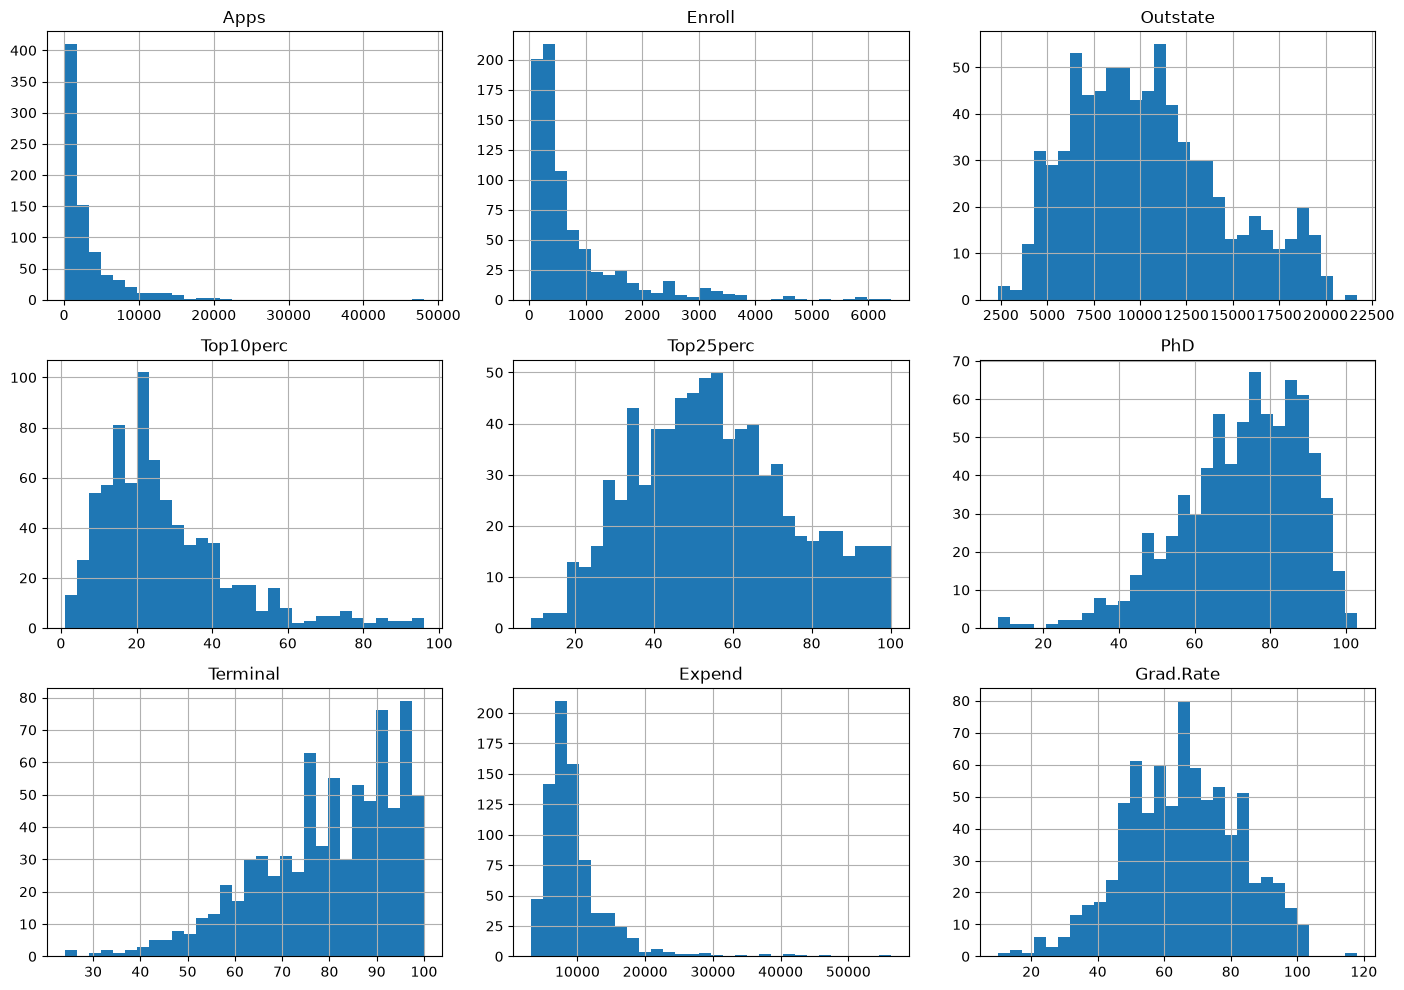

,Name,Top10perc,Top25perc,PhD,Terminal,Grad.Rate
95,Cazenovia College,9,35,22,47,118
582,Texas A&M University at Galveston,22,47,103,88,43


In [9]:
college[cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

#Percentages cannot be above 100
pct_cols = ['Top10perc', 'Top25perc', 'PhD', 'Terminal', 'Grad.Rate']
college[(college[pct_cols] > 100).any(axis=1)][['Name'] + pct_cols]

In [10]:
#Remove the rows with impossible percentages
clean = college[~(college[pct_cols] > 100).any(axis=1)].reset_index(drop=True)
print('Rows before:', len(college), 'Rows after:', len(clean))
clean[cols].skew()

Rows before: 777 Rows after: 775


Apps         3.720947
Enroll       2.686118
Outstate     0.507672
Top10perc    1.410951
Top25perc    0.255476
PhD         -0.760823
Terminal    -0.816243
Expend       3.454930
Grad.Rate   -0.144042
dtype: float64

**My answer to (a):** There are no missing values. Apps, Enroll and Expend are strongly skewed to the right, because a few very big schools have far larger numbers than the rest. Top10perc is also a bit skewed to the right. PhD and Terminal lean a little to the left, and Outstate, Top25perc and Grad.Rate look fairly even. I found two rows that cannot be right. Cazenovia College has a graduation rate of 118%, and Texas A&M University at Galveston has a PhD value above 100%. A percentage cannot go above 100, so I treated these as data errors and removed the two rows, which leaves 775 colleges. I did not remove the big schools with very high Apps or Expend. They are real colleges, not mistakes, and linear regression only needs the errors to be roughly even, not the predictors to look bell shaped. I kept the variables as they are so the results are easy to read.

###(b) What is multicollinearity, and why is it a problem for a regression with multiple predictors? Compute the correlation matrix for all eight predictors and identify any strongly correlated pairs. Then compute the Variance Inflation Factor (VIF) for each predictor. Do the pairs you flagged from the correlation matrix match the predictors with VIF > 5? If not, explain the discrepancy and explain why VIF can detect multicollinearity that is not apparent from pairwise correlations.

In [11]:
corr = clean[predictors].corr()
display(corr.round(2))

#Strongly correlated pairs (above 0.8)
pairs = [(a, b, round(corr.loc[a, b], 2)) for i, a in enumerate(predictors) for b in predictors[i+1:] if abs(corr.loc[a, b]) > 0.8]
print(pairs)

Xc = sm.add_constant(clean[predictors])
vif = pd.Series([variance_inflation_factor(Xc.values, i + 1) for i in range(len(predictors))], index=predictors)
vif.round(2)

,Apps,Enroll,Outstate,Top10perc,Top25perc,PhD,Terminal,Expend
Apps,1.00,0.85,0.05,0.34,0.35,0.40,0.37,0.26
Enroll,0.85,1.00,-0.16,0.18,0.23,0.33,0.31,0.06
Outstate,0.05,-0.16,1.00,0.56,0.49,0.39,0.41,0.67
Top10perc,0.34,0.18,0.56,1.00,0.89,0.53,0.49,0.66
Top25perc,0.35,0.23,0.49,0.89,1.00,0.55,0.52,0.53
PhD,0.40,0.33,0.39,0.53,0.55,1.00,0.85,0.44
Terminal,0.37,0.31,0.41,0.49,0.52,0.85,1.00,0.44
Expend,0.26,0.06,0.67,0.66,0.53,0.44,0.44,1.00


[('Apps', 'Enroll', np.float64(0.85)), ('Top10perc', 'Top25perc', np.float64(0.89)), ('PhD', 'Terminal', np.float64(0.85))]


Apps         4.28
Enroll       4.31
Outstate     2.27
Top10perc    6.63
Top25perc    5.48
PhD          3.92
Terminal     3.82
Expend       2.54
dtype: float64

**My answer to (b):** Multicollinearity is when two or more predictors move together, so they carry almost the same information. It is a problem because the model cannot tell which predictor is doing the work. The coefficients become unstable, their standard errors get bigger, and a useful predictor can look not significant. Predictions can still be fine, but the story told by the coefficients is not reliable.

The correlation matrix flags three strong pairs: Apps and Enroll (0.85), Top10perc and Top25perc (0.89), and PhD and Terminal (0.85). The VIF values do not match this fully. Only Top10perc (about 6.6) and Top25perc (about 5.5) are above 5. Apps, Enroll, PhD and Terminal are all below 5 (between about 3.8 and 4.3), even though they sit in strongly correlated pairs. The reason is that a VIF measures how well one predictor can be explained by all the other predictors together, not just one at a time. Top10perc and Top25perc are also related to Outstate and Expend (correlations of about 0.5 to 0.7), so they get pushed over 5. The other pairs are mostly tied to each other and much less to the rest. This also shows why VIF is useful. A predictor can be explained by a mix of several others even when no single pair looks very high, and the correlation matrix would miss that. Top10perc has the highest VIF, so I treat it as the worst one and remove it.

###(c) After removing the worst multicollinear predictor, use stepwise regression to build linear regression models via forward(entry p < 0.05) and backward(removal p > 0.10) selection on the remaining seven predictors. Report which predictors both directions agree on, and which they disagree on, and explain why. Which model has the better adjusted R² and cross-validated RMSE using 10 folds?

In [12]:
final_preds = [p for p in predictors if p != 'Top10perc']
y = clean[target]
kf = KFold(n_splits=10, shuffle=True, random_state=1)

def fit_ols(feats):
    return sm.OLS(y, sm.add_constant(clean[feats])).fit()

def cv_rmse(feats):
    scores = cross_val_score(LinearRegression(), clean[feats], y, cv=kf, scoring='neg_root_mean_squared_error')
    return -scores.mean()

def forward_select(cands, alpha=0.05):
    chosen = []
    while True:
        pvals = {c: fit_ols(chosen + [c]).pvalues[c] for c in cands if c not in chosen}
        if not pvals:
            break
        best = min(pvals, key=pvals.get)
        if pvals[best] < alpha:
            chosen.append(best)
        else:
            break
    return chosen

def backward_select(cands, alpha=0.10):
    chosen = list(cands)
    while chosen:
        pvals = fit_ols(chosen).pvalues.drop('const')
        worst = pvals.idxmax()
        if pvals[worst] > alpha:
            chosen.remove(worst)
        else:
            break
    return chosen

fwd = forward_select(final_preds)
bwd = backward_select(final_preds)
print('Forward :', fwd)
print('Backward:', bwd)
print('Both agree on:', [p for p in fwd if p in bwd])
print('Only in backward:', [p for p in bwd if p not in fwd])

pd.DataFrame({m: {'Adjusted R2': fit_ols(f).rsquared_adj, 'CV RMSE (10 fold)': cv_rmse(f)} for m, f in [('Forward', fwd), ('Backward', bwd)]}).T

Forward : ['Outstate', 'Top25perc', 'Expend']
Backward: ['Apps', 'Enroll', 'Outstate', 'Top25perc', 'Expend']
Both agree on: ['Outstate', 'Top25perc', 'Expend']
Only in backward: ['Apps', 'Enroll']


,Adjusted R2,CV RMSE (10 fold)
Forward,0.386641,13.370414
Backward,0.394603,13.319535


**My answer to (c):** I removed Top10perc, which had the highest VIF. Forward selection kept Outstate, Top25perc and Expend. Backward selection kept those same three and also kept Apps and Enroll. So both agree on Outstate, Top25perc and Expend, and they disagree on Apps and Enroll. The reason is that Apps and Enroll are strongly correlated with each other (0.85) and they work as a pair. In the backward model Apps has a positive coefficient and Enroll has a negative one, so together they act like a contrast between how many people apply and how many actually enroll. Added one at a time, forward selection does not see enough gain from either one (Apps gets a p-value of about 0.09 once the other three are in). Backward selection starts with everything in, so both are already there, and each one stays significant because it helps correct the other. The backward model has the better adjusted R² (about 0.395 against 0.387) and the lower cross validated RMSE (about 13.32 against 13.37). The gap is small, but backward wins on both.

###(d) Compare the BIC of forward's model, backward's model, and the best-BIC model across all subsets of the seven predictors. Do BIC and your Part C accuracy comparison agree on which model is best?

In [13]:
best_bic, best_set = min((fit_ols(list(s)).bic, list(s)) for n in range(1, 8) for s in itertools.combinations(final_preds, n))
print('Best BIC subset:', best_set)

pd.DataFrame({m: {'BIC': fit_ols(f).bic} for m, f in [('Forward', fwd), ('Backward', bwd), ('Best BIC', best_set)]}).T

Best BIC subset: ['Outstate', 'Top25perc']


,BIC
Forward,6241.597969
Backward,6242.765429
Best BIC,6240.308011


**My answer to (d):** The lowest BIC belongs to the best subset model, which uses only Outstate and Top25perc (BIC about 6240.3). The forward model is next (about 6241.6) and the backward model is last (about 6242.8). So BIC does not agree with my Part C comparison. In Part C the backward model was the most accurate, but BIC ranks it the worst of the three. This makes sense because BIC punishes extra predictors heavily, and the backward model has five predictors for only a small gain in fit. BIC prefers the simpler model, while adjusted R² and cross validated RMSE only care a little about the number of predictors.

###(e) Fit a full model using all seven remaining predictors and compute its adjusted R² and cross-validated RMSE using 10 folds. Compare all four models: forward's, backward's, the best-BIC model from part D, and this full model, and identify the most accurate one.

In [14]:
models = {'Forward': fwd, 'Backward': bwd, 'Best BIC': best_set, 'Full (7 predictors)': final_preds}
pd.DataFrame({m: {'Adjusted R2': fit_ols(f).rsquared_adj, 'CV RMSE (10 fold)': cv_rmse(f), 'BIC': fit_ols(f).bic} for m, f in models.items()}).T

,Adjusted R2,CV RMSE (10 fold),BIC
Forward,0.386641,13.370414,6241.597969
Backward,0.394603,13.319535,6242.765429
Best BIC,0.383182,13.402877,6240.308011
Full (7 predictors),0.395267,13.357204,6253.201686


**My answer to (e):** The full model has an adjusted R² of about 0.395 and a cross validated RMSE of about 13.36. Here is how the four compare. Forward has 0.387 and 13.37, backward has 0.395 and 13.32, best BIC has 0.383 and 13.40, and the full model has 0.395 and 13.36. The backward model is the most accurate, since it has the lowest cross validated RMSE and an adjusted R² that is level with the full model. The full model comes second. The differences are tiny, only about 0.1 in RMSE, so in practice all four models predict about equally well. If I only cared about accuracy I would pick the backward model. If I wanted the simplest model that still does a decent job, I would pick the best BIC model with just Outstate and Top25perc.

##Question 3

Q3: Open study ((20 points)

Design and undertake a study to assess a trend in the domain of transport for one or more countries of your choice. Your study should be based on publicly available data and explained using mathematical facts. Explain assumptions, methodology, and findings. An example would be to study the relationship between an increase in transport and road traffic accidents. The World Health Organization has data for road traffic deaths per country, and there is a World Bank indicator for Passenger cars (per 1000 people). Can historical data help predict changes in road traffic deaths? Evaluate your prediction using observations not included in model fitting.

Deliverables: You should turn in a report that includes the trend you are studying, the data source, your assumptions, the methodology used along with its implementation in MATLAB/Python, and finally the findings and conclusions, which should be backed with code and figures.

Dataset: [Mortality caused by road traffic injury (per 100,000 population)](https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project4/data/sl_folder/API_SH.STA.TRAF.P5_DS2_en_csv_v2_2491.csv)

###The trend I am studying, the data source and my assumptions

**The trend:** I am studying the road traffic death rate in four countries: Nigeria, Ghana, South Africa and the United States. I picked them because they are very different. Three are in Africa with different levels of income and road safety, and one is a rich country with a long history of road safety rules. The question I want to answer is: can the past trend in road traffic deaths help me predict the deaths in later years?

**The data source:** The data is the World Bank indicator SH.STA.TRAF.P5, which is the number of road traffic deaths per 100,000 people. The World Bank takes it from the World Health Organization. It is the same data the question talks about. I did not use the passenger cars indicator because it was not in the files I was given, so I only use time (year) to explain the deaths.

**My assumptions:**
1. The numbers from the World Health Organization are a fair picture of the real deaths in each country.
2. Using a rate per 100,000 people already takes care of population growth, so I can compare years fairly.
3. I treat the change over the years as a straight line over a short time. This is the simple idea I want to test.
4. The yearly errors around the line are independent and roughly normal. I check this later.
5. Whatever was driving the deaths before 2015 may continue after 2015. I test this directly and do not just trust it.

**My method:** I use the years 2000 to 2014 (15 years) to fit the models. I keep the years 2015 to 2019 (5 years) out of the fitting and use them only to test the predictions. I compare three models: a straight line on time, a quadratic curve on time, and a very simple one that just repeats the last known value (2014). The simple one is a baseline. If my fancy model cannot beat it, then the model is not adding real value. I judge them with the root mean squared error (RMSE) on the test years.

###Step 1: Load and prepare the data

In [15]:
url = 'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project4/data/sl_folder/API_SH.STA.TRAF.P5_DS2_en_csv_v2_2491.csv'
raw = pd.read_csv(url, skiprows=4)
countries = ['Nigeria', 'Ghana', 'South Africa', 'United States']
years = [str(y) for y in range(2000, 2020)]
wide = raw[raw['Country Name'].isin(countries)].set_index('Country Name')[years].T
wide.index = wide.index.astype(int)
wide = wide[countries]
print('Missing values:', wide.isna().sum().sum())
wide.describe().T.round(2)

Missing values: 0


,count,mean,std,min,25%,50%,75%,max
Country Name,,,,,,,,
Nigeria,20.0,24.68,3.21,20.7,21.78,25.10,27.15,29.8
Ghana,20.0,24.66,0.91,23.3,23.90,24.60,25.52,25.9
South Africa,20.0,31.22,7.80,22.2,24.08,28.60,38.70,44.0
United States,20.0,13.60,1.84,11.3,12.05,12.85,15.70,16.2


**My thoughts on step 1:** The data has 20 years (2000 to 2019) for each of the four countries and there are no missing values, so I did not have to remove or fill in anything. The table shows that South Africa has the highest and most spread out death rate (average of about 31, going from 22 to 44). The United States has the lowest (average of about 14). Ghana is very steady, with a standard deviation of only about 0.9, while Nigeria moves a little more.

###Step 2: Look at the trend over time

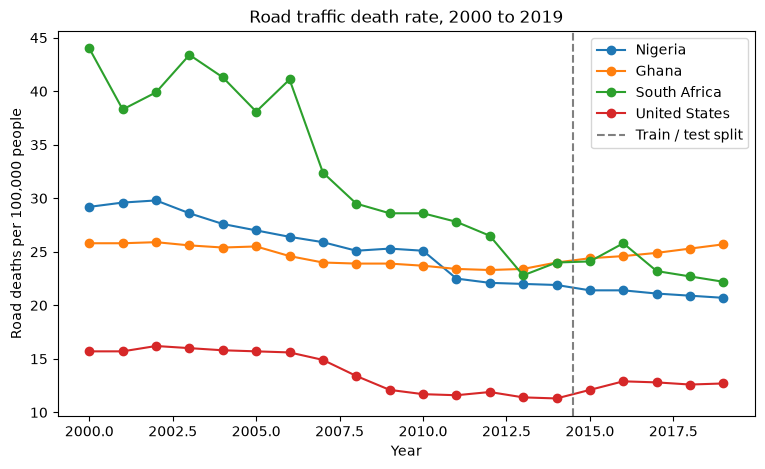

In [16]:
wide.plot(figsize=(9, 5), marker='o')
plt.axvline(2014.5, color='grey', linestyle='--', label='Train / test split')
plt.xlabel('Year')
plt.ylabel('Road deaths per 100,000 people')
plt.title('Road traffic death rate, 2000 to 2019')
plt.legend()
plt.show()

**My thoughts on step 2:** Before 2015, three of the four countries show a clear drop. South Africa falls the most, from 44 down to about 24. Nigeria falls slowly from about 30 to 22. The United States falls from about 16 to 11.3 in 2014. Ghana is almost flat. After the dashed line (2015 on), the picture changes. The United States and Ghana start to go back up, and South Africa and Nigeria level out. So the downward trend does not seem to keep going, and this is exactly what I want to test.

###Step 3: Fit the models on 2000 to 2014 and test them on 2015 to 2019

In [17]:
train_years = np.arange(2000, 2015)
test_years = np.arange(2015, 2020)

def rmse(a, b):
    return np.sqrt(np.mean((np.array(a) - np.array(b)) ** 2))

rows = []
fits = {}
for c in countries:
    ytr = wide.loc[train_years, c].values
    yte = wide.loc[test_years, c].values
    s = stats.linregress(train_years, ytr)
    lin_pred = s.intercept + s.slope * test_years
    quad = np.polyfit(train_years - 2000, ytr, 2)
    quad_pred = np.polyval(quad, test_years - 2000)
    naive_pred = np.repeat(ytr[-1], len(test_years))
    fits[c] = (s, lin_pred, quad_pred, naive_pred)
    rows.append({'Country': c, 'Slope (per year)': s.slope, 'Train R squared': s.rvalue ** 2,
                 'Slope p-value': s.pvalue,
                 'Test RMSE linear': rmse(yte, lin_pred),
                 'Test RMSE quadratic': rmse(yte, quad_pred),
                 'Test RMSE last value': rmse(yte, naive_pred),
                 'Test mean of actual': yte.mean()})
results = pd.DataFrame(rows).set_index('Country')
results.round(3)

,Slope (per year),Train R squared,Slope p-value,Test RMSE linear,Test RMSE quadratic,Test RMSE last value,Test mean of actual
Country,,,,,,,
Nigeria,-0.614,0.956,0.0,1.490,2.190,0.846,21.10
Ghana,-0.206,0.849,0.0,2.611,1.751,1.087,24.98
South Africa,-1.540,0.870,0.0,5.439,8.682,1.328,23.60
United States,-0.419,0.856,0.0,2.979,4.484,1.349,12.62


**My thoughts on step 3:** On the training years the straight line fits very well. R squared is between 0.85 and 0.96 and every slope p-value is far below 0.05, so the downward trends are real and not just luck. The yearly slopes are about -0.61 for Nigeria, -0.21 for Ghana, -1.54 for South Africa and -0.42 for the United States (deaths per 100,000 people each year).

The test results tell a different story. For all four countries, the simple "last value" baseline has the lowest test RMSE (between about 0.85 and 1.35). The straight line is worse (1.49 to 5.44) and the quadratic curve is mostly the worst (up to 8.68 for South Africa). The only small exception is Ghana, where the quadratic is better than the line but still worse than the baseline. So a model that looked great on the past data did a worse job on the new data than just repeating the last number.

###Step 4: Look at the forecasts against what really happened

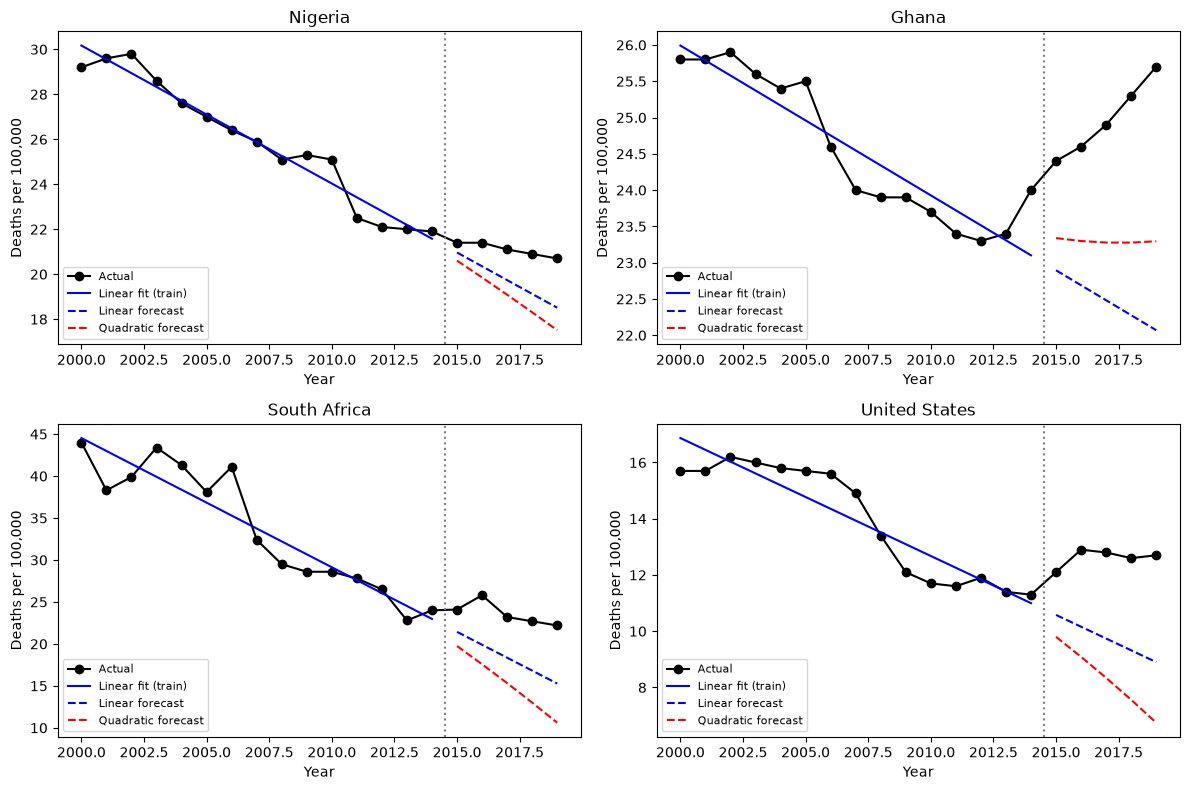

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, c in zip(axes.ravel(), countries):
    s, lin_pred, quad_pred, naive_pred = fits[c]
    ax.plot(wide.index, wide[c], 'ko-', label='Actual')
    ax.plot(train_years, s.intercept + s.slope * train_years, 'b-', label='Linear fit (train)')
    ax.plot(test_years, lin_pred, 'b--', label='Linear forecast')
    ax.plot(test_years, quad_pred, 'r--', label='Quadratic forecast')
    ax.axvline(2014.5, color='grey', linestyle=':')
    ax.set_title(c)
    ax.set_xlabel('Year')
    ax.set_ylabel('Deaths per 100,000')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**My thoughts on step 4:** The plots show why the line and curve fail. In South Africa the line keeps going down to about 15, but the real value stays near 23 to 24, so the drop stopped. In Nigeria the line goes down faster than the real values do. In the United States and Ghana the line keeps going down, but the real values go up after 2014. The quadratic curve is even more extreme because it bends and swings away from the data. This is a common problem when I use a curve outside the range of the data I used to build it.

###Step 5: Check my assumptions and the prediction intervals

In [19]:
#Check the leftover errors of the linear model on the training years
for c in countries:
    s = fits[c][0]
    resid = wide.loc[train_years, c].values - (s.intercept + s.slope * train_years)
    print(c, '| residual std:', round(resid.std(ddof=2), 3),
          '| Shapiro p-value:', round(stats.shapiro(resid).pvalue, 3),
          '| lag 1 autocorrelation:', round(np.corrcoef(resid[:-1], resid[1:])[0, 1], 3))

#95% prediction interval for the linear model and how many test points fall inside it
from scipy.stats import t as tdist
for c in countries:
    s = fits[c][0]
    ytr = wide.loc[train_years, c].values
    n = len(train_years)
    se = np.sqrt(np.sum((ytr - (s.intercept + s.slope * train_years)) ** 2) / (n - 2))
    xbar = train_years.mean()
    sxx = np.sum((train_years - xbar) ** 2)
    half = tdist.ppf(0.975, n - 2) * se * np.sqrt(1 + 1 / n + (test_years - xbar) ** 2 / sxx)
    pred = s.intercept + s.slope * test_years
    inside = ((wide.loc[test_years, c].values >= pred - half) & (wide.loc[test_years, c].values <= pred + half)).sum()
    print(c, '| test points inside 95% interval:', inside, 'of', len(test_years))

Nigeria | residual std: 0.611 | Shapiro p-value: 0.545 | lag 1 autocorrelation: 0.133
Ghana | residual std: 0.404 | Shapiro p-value: 0.391 | lag 1 autocorrelation: 0.536
South Africa | residual std: 2.756 | Shapiro p-value: 0.9 | lag 1 autocorrelation: 0.262
United States | residual std: 0.799 | Shapiro p-value: 0.514 | lag 1 autocorrelation: 0.743
Nigeria | test points inside 95% interval: 3 of 5
Ghana | test points inside 95% interval: 0 of 5
South Africa | test points inside 95% interval: 5 of 5
United States | test points inside 95% interval: 1 of 5


**My thoughts on step 5:** The errors from the line on the training years look normal for all four countries (the Shapiro p-values are all above 0.05), so that assumption is fine. The lag 1 autocorrelation is positive, and it is quite high for the United States (about 0.74) and Ghana (about 0.54). This means that the error in one year is related to the error in the next year, so the years are not fully independent. This makes the straight line intervals too narrow. I see this in the last results: only 0 of 5 test points fall inside the 95% interval for Ghana and 1 of 5 for the United States. Nigeria has 3 of 5. South Africa has 5 of 5, but only because its interval is very wide (the training errors are large). So the intervals from the line cannot be trusted to give a safe range here.

###Findings and conclusions

**Can historical data help predict changes in road traffic deaths?** Only a little, and only for the very short term. The trend from 2000 to 2014 is real and strong in the training data, but when I tested it on 2015 to 2019 it did not hold. In all four countries, the straight line and the quadratic curve were worse than the baseline that simply repeats the last known value.

**Why I think this happened:** The mathematical reason is that a fitted line assumes the same rate of change continues forever. The real series changed direction or slowed down after 2014. This might be because the first big gains in road safety (like seat belt laws and better roads) were already used up, and because more vehicles were on the road. I cannot prove those reasons with this data, since I only used time as the explanatory variable. I would need data like passenger cars per 1000 people to test that, and that is the next step I would take.

**What I would do differently:** I would add the passenger cars indicator and more countries, and I would use a method that is made for time series, because my errors are related from year to year. I would also test on more than five years if the data allowed it.

**Limits of the study:** There are only 20 yearly points per country, and the test set is only 5 points, so my results are not very strong. The World Health Organization numbers are estimates and not always exact counts. And fitting on time alone cannot show cause and effect.

**Main takeaway:** A model can fit the past very well and still fail on the future. That is why testing on data that was left out of the fitting is so important.

##Question 4

Q4: Model Fitting and Prediction((30 points))

By using the Dataset of the annual unemployment rate for Israel, World Bank indicator SL.UEM.TOTL.NE.ZS.

In [20]:
#Data ingestion
un_url = 'https://raw.githubusercontent.com/api-sage/diaml_projects/refs/heads/main/Project4/data/actual_sl/API_SL.UEM.TOTL.NE.ZS_DS2_en_csv_v2_4732.csv'
un_raw = pd.read_csv(un_url, skiprows=4)
row = un_raw[un_raw['Country Name'] == 'Israel'].iloc[0]
yrs = [c for c in un_raw.columns if c.isdigit()]
isr = pd.Series(row[yrs].values.astype(float), index=[int(y) for y in yrs]).dropna()
isr.index.name = 'Year'
x_all = isr.index.values.astype(float)
y_all = isr.values
print('Years:', isr.index.min(), 'to', isr.index.max(), '| Observations:', len(isr))
isr.head()

Years: 1969 to 2025 | Observations: 57


Year
1969    4.474
1970    3.824
1971    3.457
1972    2.704
1973    2.642
dtype: float64

###(a) Plot the full series. Describe, in your own words, the distinct phases visible in the data(periods of sustained rise and periods of sustained decline)

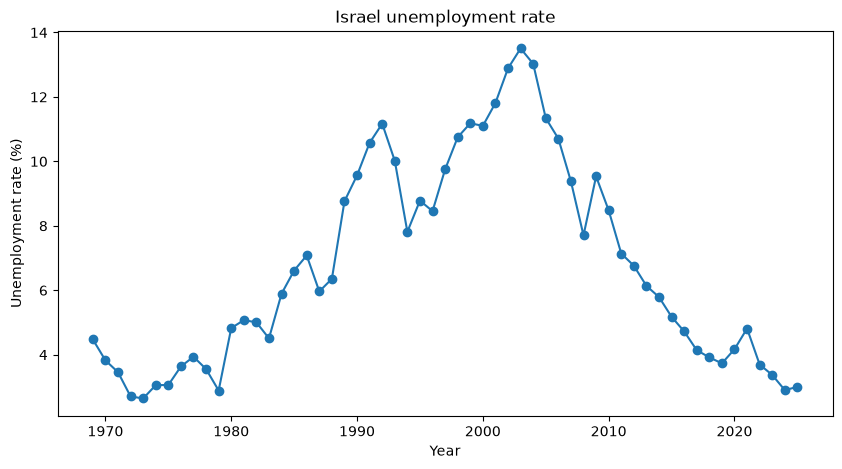

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(isr.index, isr.values, 'o-')
plt.xlabel('Year')
plt.ylabel('Unemployment rate (%)')
plt.title('Israel unemployment rate')
plt.show()

**My answer to (a):** The series has a few clear phases. From 1969 to about 1973 unemployment fell from about 4.5% to about 2.6%. From the mid 1970s to 1979 it stayed low, between about 2.9% and 3.9%. Then it started a long rise. It went up from about 2.9% in 1979 to about 11.2% in 1992. After that it dropped to about 7.8% in 1994 and then rose again, with some bumps, to a peak of about 13.5% in 2003. From 2003 the rate came down for a long time, with a small jump in 2009 and again in 2020. It reached about 2.9% in 2024 and 3.0% in 2025. So the data goes up, then down, then up, then down, and this does not look like one straight line.

###(b) Fit a linear regression of the unemployment rate on year using the entire dataset, then evaluate that same model by predicting every year in the dataset. Report the RMSE or MAE of these predictions. Plot the actual vs. predicted. Explain why the accuracy figure is not a trustworthy way to judge how well this model would perform on data it hasn't already seen.

Linear slope per year: 0.030008296603577605
Linear RMSE: 3.118917361125541 | MAE: 2.709582558938184


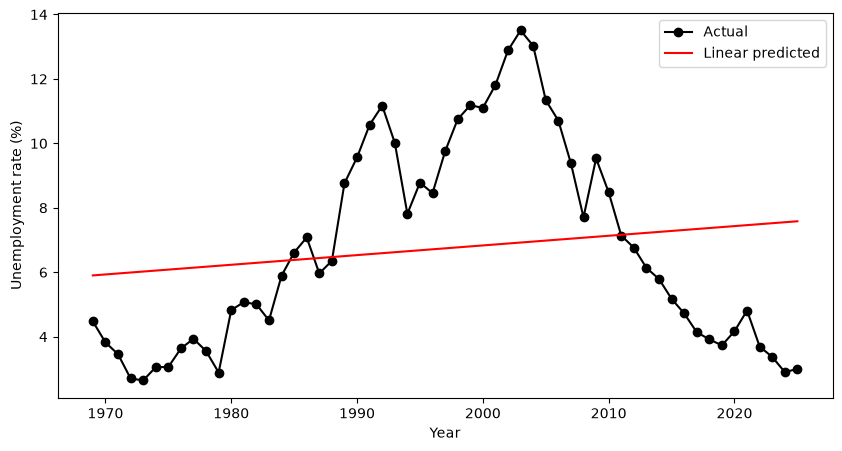

In [22]:
def rmse(a, b):
    return np.sqrt(np.mean((np.array(a) - np.array(b)) ** 2))
def mae(a, b):
    return np.mean(np.abs(np.array(a) - np.array(b)))

lin_all = np.polyfit(x_all, y_all, 1)
lin_pred_all = np.polyval(lin_all, x_all)
print('Linear slope per year:', lin_all[0])
print('Linear RMSE:', rmse(y_all, lin_pred_all), '| MAE:', mae(y_all, lin_pred_all))

plt.figure(figsize=(10, 5))
plt.plot(x_all, y_all, 'ko-', label='Actual')
plt.plot(x_all, lin_pred_all, 'r-', label='Linear predicted')
plt.xlabel('Year'); plt.ylabel('Unemployment rate (%)'); plt.legend()
plt.show()

**My answer to (b):** The linear model has an RMSE of about 3.12 and an MAE of about 2.71 percentage points. The slope is about 0.03, which is almost flat, because the early and late years are low and the middle years are high. The plot shows the line sits far from the data in many years. The accuracy number is not a trustworthy way to judge new data because the model was fitted on the same years that I used to test it. The line was picked to match these exact points, so the error only tells me how well it describes the past. It does not tell me how it will do on years it has never seen. A model can look good on the data it was trained on and still fail on new data.

###(c) Given the shape you described in (a), a straight line may not be the right form. Fit a quadratic regression, and evaluate it using the same metric as (b). Plot the actual vs. predicted. Does the model improve accuracy compared to the straight-line fit?

Quadratic RMSE: 1.676912860396674 | MAE: 1.374763531848702
Linear RMSE: 3.118917361125541 | MAE: 2.709582558938184


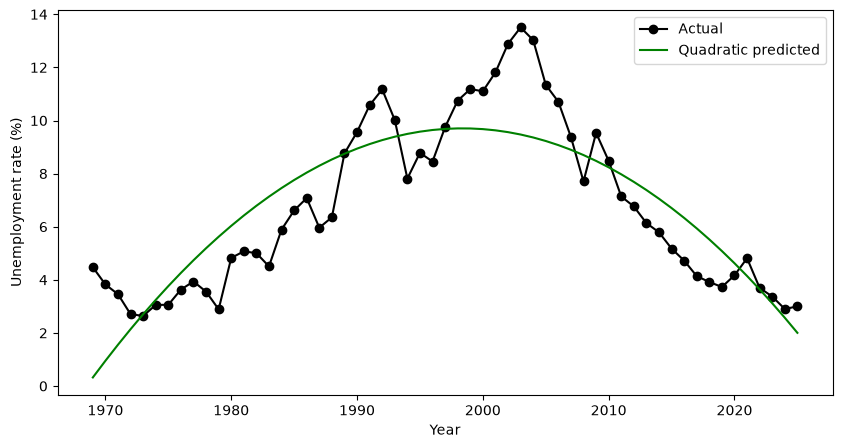

In [23]:
#Centre the year so the quadratic is numerically stable
x0 = x_all.mean()
quad_all = np.polyfit(x_all - x0, y_all, 2)
quad_pred_all = np.polyval(quad_all, x_all - x0)
print('Quadratic RMSE:', rmse(y_all, quad_pred_all), '| MAE:', mae(y_all, quad_pred_all))
print('Linear RMSE:', rmse(y_all, lin_pred_all), '| MAE:', mae(y_all, lin_pred_all))

plt.figure(figsize=(10, 5))
plt.plot(x_all, y_all, 'ko-', label='Actual')
plt.plot(x_all, quad_pred_all, 'g-', label='Quadratic predicted')
plt.xlabel('Year'); plt.ylabel('Unemployment rate (%)'); plt.legend()
plt.show()

**My answer to (c):** Yes, the quadratic model is better on this measure. Its RMSE is about 1.68 and its MAE is about 1.37, compared with 3.12 and 2.71 for the line. That is roughly half the error. The curve bends up in the middle and down at the ends, so it follows the rise and fall better. It still misses the sharp jumps, like the drop in the 1990s. Also, this is still tested on the same data it was trained on, so the improvement could partly be because a curve has more freedom to fit.

###(d) Reserve the final ten available years as a test set. Fit the linear and quadratic models using only the preceding observations. Predict the ten test years and calculate the RMSE for each model.

In [24]:
x_tr, y_tr = x_all[:-10], y_all[:-10]
x_te, y_te = x_all[-10:], y_all[-10:]
print('Train:', int(x_tr[0]), 'to', int(x_tr[-1]), '| Test:', int(x_te[0]), 'to', int(x_te[-1]))

xt0 = x_tr.mean()
lin_tr = np.polyfit(x_tr, y_tr, 1)
quad_tr = np.polyfit(x_tr - xt0, y_tr, 2)
lin_te = np.polyval(lin_tr, x_te)
quad_te = np.polyval(quad_tr, x_te - xt0)

print('Linear test RMSE:', rmse(y_te, lin_te))
print('Quadratic test RMSE:', rmse(y_te, quad_te))
pd.DataFrame({'Actual': y_te, 'Linear': lin_te, 'Quadratic': quad_te}, index=x_te.astype(int)).round(3)

Train: 1969 to 2015 | Test: 2016 to 2025
Linear test RMSE: 7.8633491088052745
Quadratic test RMSE: 1.7676728050583874


,Actual,Linear,Quadratic
2016,4.723,10.971,7.133
2017,4.140,11.121,6.804
2018,3.917,11.272,6.455
2019,3.731,11.422,6.087
2020,4.169,11.573,5.699
2021,4.812,11.723,5.291
2022,3.695,11.874,4.864
2023,3.371,12.024,4.417
2024,2.901,12.175,3.951
2025,3.000,12.325,3.465


**My answer to (d):** I used 1969 to 2015 for training and 2016 to 2025 for testing. The linear model has a test RMSE of about 7.86 and the quadratic model has a test RMSE of about 1.77. The line is far off because it predicts about 11 to 12% while the real values are about 3 to 5%. The quadratic model is much closer, but it still predicts too high in the early test years. Compared with (b) and (c), the errors on unseen years are bigger, especially for the line. This shows that the earlier numbers were too hopeful.

###(e) Now compute a naive baseline for the same test portion: predict every year using nothing but the last known value from the training portion. Report its RMSE or MAE and compare it to both the linear (b) and quadratic (c) models, as evaluated in (d). Plot the actual vs. predicted. Which of the three performs best?

Last training value: 5.176 (year 2015 )


,RMSE,MAE
Linear,7.863,7.802
Quadratic,1.768,1.571
Naive,1.465,1.330


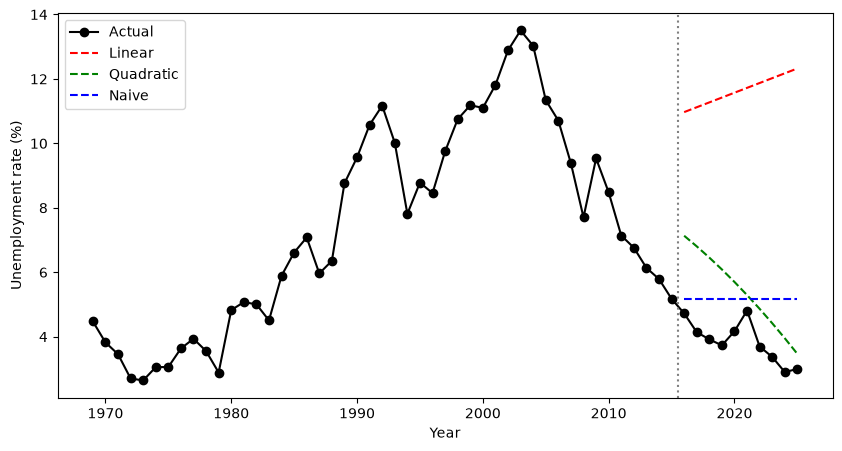

In [25]:
naive_te = np.repeat(y_tr[-1], len(y_te))
print('Last training value:', y_tr[-1], '(year', int(x_tr[-1]), ')')
res_e = pd.DataFrame({'RMSE': [rmse(y_te, lin_te), rmse(y_te, quad_te), rmse(y_te, naive_te)],
                      'MAE': [mae(y_te, lin_te), mae(y_te, quad_te), mae(y_te, naive_te)]},
                     index=['Linear', 'Quadratic', 'Naive'])
display(res_e.round(3))

plt.figure(figsize=(10, 5))
plt.plot(x_all, y_all, 'ko-', label='Actual')
plt.plot(x_te, lin_te, 'r--', label='Linear')
plt.plot(x_te, quad_te, 'g--', label='Quadratic')
plt.plot(x_te, naive_te, 'b--', label='Naive')
plt.axvline(x_tr[-1] + 0.5, color='grey', linestyle=':')
plt.xlabel('Year'); plt.ylabel('Unemployment rate (%)'); plt.legend()
plt.show()

**My answer to (e):** The naive forecast uses the 2015 value of 5.176 for every test year. Its RMSE is about 1.47 and its MAE is about 1.33. The quadratic model has an RMSE of about 1.77 and the linear model has about 7.86. So the naive baseline performs best, then the quadratic model, then the linear model. This surprised me a little, because the naive method does not learn anything. It works well here because unemployment in Israel was already falling slowly and the last value was close to the later values. The two fitted models are tied to the whole history, which includes the big hump around 2003, so they do not follow the recent level well.

###(f). Using the same training endpoint as in (e), report the absolute forecast errors of the naive model at horizons of 1, 2, and 3 years. Does it stay the same, improve, or get worse as the horizon grows? What does this tell you about how far into the future a naive-persistence estimate can reasonably be trusted?

In [26]:
h = np.array([1, 2, 3])
err_f = np.abs(y_te[:3] - y_tr[-1])
pd.DataFrame({'Year': x_te[:3].astype(int), 'Actual': y_te[:3], 'Naive forecast': y_tr[-1], 'Absolute error': err_f}, index=pd.Index(h, name='Horizon')).round(3)

,Year,Actual,Naive forecast,Absolute error
Horizon,,,,
1,2016,4.723,5.176,0.453
2,2017,4.140,5.176,1.036
3,2018,3.917,5.176,1.259


**My answer to (f):** The naive absolute errors are about 0.45 for 1 year ahead, about 1.04 for 2 years ahead and about 1.26 for 3 years ahead. So the error gets worse as the horizon grows. This makes sense because the real rate keeps moving away from the last known value while the forecast stays fixed. It tells me a naive estimate can be trusted for the very next year or so, but the further ahead I go the less I should trust it. Here the error was already more than double after 2 years.

###(g) State which of the three approaches(linear, quadratic, or naive) you would actually use to estimate the unemployment rate of Israel for 2026, and report that estimate using the refitted model on all available observations.

In [27]:
last_year = int(x_all[-1])
lin_2026 = np.polyval(lin_all, 2026)
quad_2026 = np.polyval(quad_all, 2026 - x0)
naive_2026 = y_all[-1]
print('Last observed year:', last_year, '| value:', naive_2026)
pd.Series({'Linear': lin_2026, 'Quadratic': quad_2026, 'Naive': naive_2026}, name='2026 estimate (%)').round(3)

Last observed year: 2025 | value: 3.0


Linear       7.612
Quadratic    1.414
Naive        3.000
Name: 2026 estimate (%), dtype: float64

**My answer to (g):** I would use the naive approach. It had the lowest test RMSE in (e), and 2026 is only 1 year after the last observed year, where the naive error was the smallest in (f). The estimate is the 2025 value, which is 3.0%. For comparison, the refitted linear model gives about 7.61% and the quadratic model gives about 1.41%. The linear number is clearly too high compared with recent years. The quadratic number comes from a curve that is still falling at the end of the data, and a curve like that can easily turn the other way, so I do not trust it. My estimate for Israel's unemployment rate in 2026 is about 3.0%.